In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)

data_path = "../Tick_Sightings.xlsx"
df = pd.read_excel(data_path)

df.head()


,id,date,location,species,latinName
0,02WNholuSg6ndCk4c1dA,2022-08-01T06:40:31,Manchester,Marsh tick,Ixodes apronophorus
1,02rFwLCaAwZSVxdTDicK,2014-09-12T23:33:03,London,Southern rodent tick,Ixodes acuminatus
2,05349NmKTyfUhYKZNNH0,2015-03-17T09:10:25,Glasgow,Passerine tick,Dermacentor frontalis
3,0JDKkIqLbrytQyWTq08t,2019-02-20T13:56:04,Birmingham,Passerine tick,Dermacentor frontalis
4,0Jac6jm48OtR2AMDmNZn,2017-11-30T11:50:02,Southampton,Tree-hole tick,Ixodes arboricola


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       5000 non-null   object
 1   location   5000 non-null   object
 2   species    5000 non-null   object
 3   latinName  5000 non-null   object
dtypes: object(4)
memory usage: 156.4+ KB


In [82]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).copy()

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["dayofyear"] = df["date"].dt.dayofyear

def month_to_season(m):
    if m in [12, 1, 2]:
        return "winter"
    if m in [3, 4, 5]:
        return "spring"
    if m in [6, 7, 8]:
        return "summer"
    return "autumn"

df["season"] = df["month"].apply(month_to_season)

df.head()

,date,location,species,latinName,year,month,month_name,dayofyear,season
0,2016-09-16 13:43:34,Newcastle,Southern rodent tick,Ixodes acuminatus,2016,9,September,260,autumn
1,2018-07-22 22:25:12,Nottingham,Marsh tick,Ixodes apronophorus,2018,7,July,203,summer
2,2017-12-02 17:54:08,Glasgow,Fox/badger tick,Ixodes canisuga,2017,12,December,336,winter
3,2022-11-12 02:48:43,Southampton,Marsh tick,Ixodes apronophorus,2022,11,November,316,autumn
4,2023-04-10 01:32:31,Birmingham,Passerine tick,Dermacentor frontalis,2023,4,April,100,spring


In [83]:
print("Rows:", len(df))
print("Locations:", df["location"].nunique())
print("Species:", df["species"].nunique())
print(df["location"].value_counts().head())
print(df["species"].value_counts())


Rows: 5000
Locations: 14
Species: 5
location
Nottingham    455
Birmingham    439
Bristol       391
Glasgow       385
Liverpool     385
Name: count, dtype: int64
species
Passerine tick          1112
Fox/badger tick         1037
Southern rodent tick     972
Marsh tick               949
Tree-hole tick           930
Name: count, dtype: int64


In [84]:
species_by_loc = (
    df.groupby(["location", "species"])["id"]
      .count()
      .reset_index(name="count")
      .sort_values(["location", "count"], ascending=[True, False])
)

species_by_loc.head(10)

KeyError: 'Column not found: id'

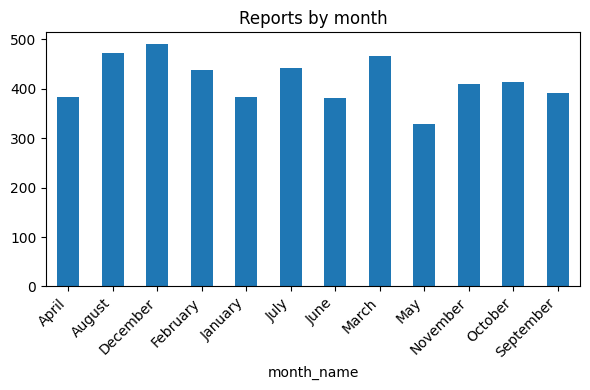

In [85]:
month_counts = df.groupby("month_name")["species"].count()

month_counts.plot(kind="bar", title="Reports by month")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [79]:
synth_df = pd.read_csv("../synthetic_sightings.csv").drop(columns=["id"], errors="ignore")
common_cols = [col for col in synth_df.columns if col in df.columns]

synth_df = synth_df[common_cols]

combined_df = pd.concat([df, synth_df], ignore_index=True)
old_df = df.copy()
df = combined_df.copy()

In [80]:
df = synth_df.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       5000 non-null   object
 1   location   5000 non-null   object
 2   species    5000 non-null   object
 3   latinName  5000 non-null   object
dtypes: object(4)
memory usage: 156.4+ KB


In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [71]:
feature_cols_cat = ["location", "season"]
feature_cols_num = ["year", "month"]
target_col = "species"

X = df[feature_cols_cat + feature_cols_num]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, feature_cols_cat),
        ("num", "passthrough", feature_cols_num),
    ]
)



In [72]:
log_reg_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(max_iter=200, multi_class="multinomial")),
    ]
)

log_reg_clf.fit(X_train, y_train)

y_pred_lr = log_reg_clf.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression accuracy: {acc_lr:.3f}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression accuracy: 0.251
                      precision    recall  f1-score   support

     Fox/badger tick       0.30      0.25      0.27       207
          Marsh tick       0.19      0.12      0.15       190
      Passerine tick       0.24      0.32      0.28       223
Southern rodent tick       0.27      0.30      0.29       194
      Tree-hole tick       0.23      0.25      0.24       186

            accuracy                           0.25      1000
           macro avg       0.25      0.25      0.24      1000
        weighted avg       0.25      0.25      0.25      1000



c:\Users\marii\Desktop\plcmnt\elanco_task\elanco_placement\backend\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\marii\Desktop\plcmnt\elanco_task\elanco_placement\backend\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


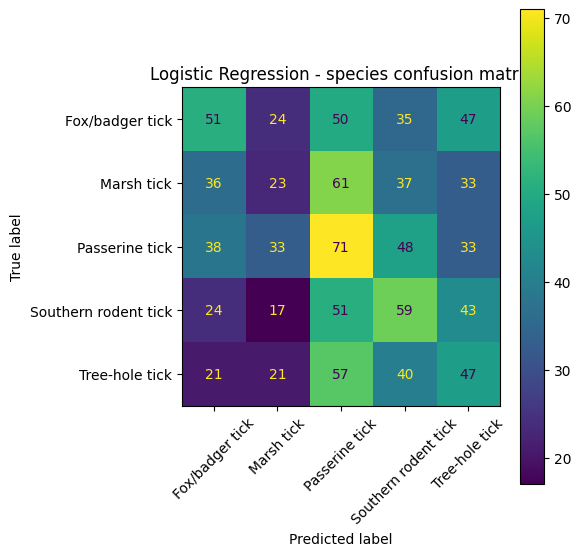

In [73]:
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax, xticks_rotation=45)
plt.title("Logistic Regression - species confusion matrix")
plt.tight_layout()
plt.show()

In [74]:
rf_clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        )),
    ]
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest accuracy: {acc_rf:.3f}")
print(classification_report(y_test, y_pred_rf))

Random Forest accuracy: 0.852
                      precision    recall  f1-score   support

     Fox/badger tick       0.87      0.85      0.86       207
          Marsh tick       0.84      0.85      0.85       190
      Passerine tick       0.87      0.86      0.86       223
Southern rodent tick       0.88      0.81      0.84       194
      Tree-hole tick       0.80      0.90      0.85       186

            accuracy                           0.85      1000
           macro avg       0.85      0.85      0.85      1000
        weighted avg       0.85      0.85      0.85      1000



In [86]:
X_old = old_df[feature_cols_cat + feature_cols_num]
y_old = old_df[target_col]

y_pred_rf_old = rf_clf.predict(X_old)
acc_rf_old = accuracy_score(y_old, y_pred_rf_old)
print(f"Random Forest accuracy on old_df: {acc_rf_old:.3f}")
print(classification_report(y_old, y_pred_rf_old))

Random Forest accuracy on old_df: 0.850
                      precision    recall  f1-score   support

     Fox/badger tick       0.86      0.86      0.86       210
          Marsh tick       0.84      0.84      0.84       186
      Passerine tick       0.87      0.84      0.85       226
Southern rodent tick       0.87      0.82      0.84       192
      Tree-hole tick       0.82      0.89      0.85       186

            accuracy                           0.85      1000
           macro avg       0.85      0.85      0.85      1000
        weighted avg       0.85      0.85      0.85      1000



In [88]:
from joblib import dump

dump(rf_clf, "../../backend/ml/rf_species_model.joblib")
print("Saved model")

Saved model


In [89]:
import numpy as np
import pandas as pd

rf = rf_clf.named_steps["clf"]

pre = rf_clf.named_steps["preprocess"]

cat_encoder = pre.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(feature_cols_cat)

num_feature_names = np.array(feature_cols_num)

all_feature_names = np.concatenate([cat_feature_names, num_feature_names])

importances = rf.feature_importances_

feat_imp = (
    pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

feat_imp.head(20)


,feature,importance
18,year,0.528266
19,month,0.182022
9,location_Manchester,0.019577
1,location_Bristol,0.019427
12,location_Sheffield,0.019161
11,location_Nottingham,0.018551
13,location_Southampton,0.018312
4,location_Glasgow,0.018305
7,location_Liverpool,0.017923
0,location_Birmingham,0.017707
